# Machine learning and unsupervised learning <a id='unsupervised_learning'></a>

Chapter 1 of Hull starts with a discussion of **machine learning**, data needs, and how to categorize different types of machine learning. Machine learning is a combination of **statistics** and **computer science**. It is a way to use data to make **predictions**. A lot of the machine learning math has been around a while, but really became useful with more data, more storage, and more computing power.

Machine learning and **artificial intelligence** are related.

Traditionally, economics and econometrics more specifically have been concerned with **causality**. Causality is a subtle, complicated idea. It is not the same as correlation. Causality is about understanding the **mechanism** behind a relationship. Machine learning is more about **prediction**. It is about using data to make predictions, and it does not (necessarily) care about the underlying mechanism. To understand the mechanism, we often want to have a **theory**.

Think about developing a drug. You want to understand how the drug works. You want to understand the biology. You want to know how it interacts with the body. You want to know how it interacts with other drugs. You want to know how it interacts with different people. If the drug does work, you want to understand **why**. 

Machine learning is about **patterns** in data. It is traditionally about using data to make predictions. In practice, machine learning and causal inference is often used together now.

**Finance is a tricky example of machine learning**. We don't have as much data as, say, image recognition. The images also don't know that you are trying to categorize them, to predict them. The fact that someone is trying to predict a future stock price changes the stock price and affects the prediction process. 

Of course, some areas of finance have more data than others. For example, if you are trying to understand the limit-order book and your trading costs, that's more data than looking at quarterly accounting statements.

This is nice summary of how we are using machine learning in finance: <https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4501707>. The authors are academics, but one of them also works at a hedge fund. The first chapter discusses some of the tensions between prediction and causality that I mention above.

Roughly speaking, there are two main types of machine learning:

1. **Supervised learning**: This is where you have a target variable. You are trying to predict something. You have a set of features and a target variable. You are trying to understand the relationship between the features and the target variable. You are trying to predict the target variable using the features.
   
2. **Unsupervised learning**: This is where you do not have a target variable. You are trying to understand the structure of the data. You are trying to find patterns in the data. You are trying to cluster the data.

There are others, but this is a helpful heuristic. 

We'll start with unsupervised learning below.

------------

## Unsupervised Learning <a id='unsupervised_learning'></a>


These notes follow along with **Chapter 2 of our Hull textbook**. My notes are not meant to be comprehensive. Instead, I want to provide you with some additional resources and commentary on what is in this chapter.

As noted in Chapter 2,

> ... unsupervised learning is concerned with **identifying patterns in data**. The immediate objective is not to predict  the value of a target variable. Instead, it is to understand the **structure** of data and find **clusters**.

## Feature Scaling

The chapter starts with a particular **transformation** of our data. We've already seen a bit about how to take our raw data and create new variables from it. This broad topic is called **feature engineering**. It is a crucial part of data analysis, as you are rarely taking raw data and using it to make a prediction or investigate a causal relationship.

Instead, you need to change your variables. Scale or normalize them. Create categories. Take logs. All to help with interpretation and create better models.

The purpose of feature scaling is to ensure that the features are given equal importance in a model. You're trying to capture how different a variable is from its typical value and whether or not this relates to some other value, the one that you're trying to predict.

The text discusses **normalization**. You've probably seen this calculation in your stats class.

\begin{align}
\text{Scaled Feature Value} = \frac{V - \mu}{\sigma}
\end{align}

where V is the value of an observation, $\mu$ is the mean of all of the observations, and $\sigma$ is the standard deviation of the values. This is called a **Z-score normalization**.

You can also do **min-max scaling**. 

\begin{align}
\text{Scaled Feature Value} = \frac{V - min(V)}{max(V) - min(V)}
\end{align}

Finally, note that use of **training set** and **validation set**. We are going to start splitting our data up as we use **machine learning** techniques to make predictions. We use these data sets to build our model and, in particular, look for **hyperparameters**, a subject we'll get to when discussing regression and logit in Chapter 3 of Hull. We'll also create a **testing set** where we take the trained model and see how well it **predicts values** using data we've **pulled out** and not used. 

Hull points out that, when scaling your data, you should **pull the means and standard deviations that you need from the training data**. Then, you **scale your testing data using the means and standard deviations from the training data**. That way, your testing data never touches your training data. If you use the means and standard deviations from all of your data to scale your variables, then observations in your testing data set are altering observations in your training data set, and vice-versa.

### Additional materials on feature engineering

Here are some examples from Datacamp on [feature engineering for a Kaggle competition](https://www.datacamp.com/tutorial/feature-engineering-kaggle). Again, this is all about variable transformation and, more generally, **data engineering**. For example, see the example on **binning data**? This is like when we created some categories for house sizes in our problem sets.

Here's an [entire book on feature engineering](https://feaz-book.com). It is a work in progress, but gives you a sense for the types of transformations that you can make and why you might want to make them.

The Feature Engineering book has a section on [normalization](https://feaz-book.com/numeric-normalization).



## K-means Algorithm

**Clustering** is about grouping our data. How are some observations like others? To do this, we are going to use the concept of a **distance** between observations. Are some observations closer to others, in some sense?

We are going to use [Kmeans from scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html). 

Our text discusses **Euclidean distance** on pgs. 25 and 26. This is like measuring the length of a line, except that you can do this in any number of dimensions.

There is also the concept of a **center** of a cluster. Suppose that a certain set of observations is regarded as a cluster. The center is calculated by averaging the values of each of the features for the observations in the cluster.


```{figure} ../images/10-kmeansalgo.png
---
name: 10-kmeansalg.png
align: center
---
How the algo works. From Hull, Chapter 2.
```

How do you know if your clustering method is any good? A measure of the performance of a clustering algorithm is the within-cluster sum of squares, also known as the **inertia**. Define $d_i$ as the  distance of the ith observation from the center of the cluster to which it belongs.

\begin{align}
\text{Inertia} = \sum_{i=1}^{N} d_i
\end{align}

The larger the inertia value, the worse the fit. Now, you can always get smaller inertia by adding more clusters. In fact, each observation could be its own cluster! But, that defeats the purpose. At some point, there's an "optimal" number of clusters to try and divide your data into.

The example below will use the **elbow method**. Sometimes, there's just a natural number of clusters that you're looking for. 

The text also discusses the **silhouette method** and **gap method** for choosing the optimal number of clusters. You want larger silhouette scores as you vary the number of clusters, k. You'll also see an example of this below.

Finally, the text discusses the **curse of dimensionality**. Basically, as you have more and more features, forming clusters gets difficult. There are other ways to cluster your data, beyond Euclidean Distance. For example, the text mentions **cosine similarity**.

In the example below, we'll start with four features. But, two of them are highly correlated, so we drop one. This is where **looking at and understanding your data first is crucial**.



### The intuition

Here is a simple way to think about K-means. Imagine you're sorting countries into groups based on their risk characteristics. You don't know ahead of time which countries belong together — you just have the data and a guess about how many groups (k) there should be.

K-means works like this:

1. **Start**: Drop k pins randomly in the space of your data. These are the initial cluster **centroids**.
2. **Assign**: Each country looks at all k centroids and says "I belong to the one closest to me."
3. **Update**: Each centroid moves to the average position of all the countries assigned to it.
4. **Repeat**: Keep assigning and updating until no country switches groups.

The algorithm converges when the centroids stop moving. The result is k groups where each member is closer to its own group's center than to any other group's center.

The challenge is choosing k — how many clusters? We'll use the **elbow method** and **silhouette scores** below to help with this decision.

## An example with country risk

I have re-created the code for this section below. We are now using the `scikit-learn` package. This is where the `KMeans` algo lives. I have uploaded the raw country risk data to our course Github page.

You can install `scikit-learn` with `pip`.

```

pip install -U scikit-learn

```

There is a bug with a package called `threadpoolctl` and `scikit-learn`. `threadpoolctl` needs to be version 3 or higher. This may not be an issue when running things in Github Codespaces, but it was on my local Mac install. You can get a later version by specifying the one that you want to install.

```
 pip install threadpoolctl==3.2.0

```



In [1]:
# Our set-up

import pandas as pd
import numpy as np

# plotting packages
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as clrs

# Kmeans algorithm from scikit-learn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
# load raw data

raw = pd.read_csv('https://raw.githubusercontent.com/aaiken1/fin-data-analysis-python/main/data/Country_Risk_2019_Data.csv')

# check the raw data
print("Size of the dataset (row, col): ", raw.shape)
print("\nFirst 5 rows\n", raw.head(n=5))

Size of the dataset (row, col):  (121, 6)

First 5 rows
      Country Abbrev  Corruption  Peace  Legal  GDP Growth
0    Albania     AL          35  1.821  4.546       2.983
1    Algeria     DZ          35  2.219  4.435       2.553
2  Argentina     AR          45  1.989  5.087      -3.061
3    Armenia     AM          42  2.294  4.812       6.000
4  Australia     AU          77  1.419  8.363       1.713


### Simple exploratory analysis
#### Print summary statistics
Note that all features have quite different variances, and Corruption and Legal are highly correlated.

In [3]:
# print summary statistics
print("\nSummary statistics\n", raw.describe())
print("\nCorrelation matrix\n", raw.corr(numeric_only=True))


Summary statistics
        Corruption       Peace       Legal  GDP Growth
count  121.000000  121.000000  121.000000  121.000000
mean    46.842975    2.001017    5.752529    2.657529
std     18.702499    0.461485    1.373932    2.563741
min     15.000000    1.072000    2.671000   -9.459000
25%     33.000000    1.699000    4.785000    1.249000
50%     41.000000    1.939000    5.455000    2.600000
75%     60.000000    2.294000    6.488000    4.000000
max     87.000000    3.369000    8.712000    7.800000

Correlation matrix
             Corruption     Peace     Legal  GDP Growth
Corruption    1.000000 -0.705002  0.938512   -0.123545
Peace        -0.705002  1.000000 -0.662233   -0.004428
Legal         0.938512 -0.662233  1.000000   -0.150369
GDP Growth   -0.123545 -0.004428 -0.150369    1.000000


#### Plot histogram

Note that the distribution for GDP Growth is quite skewed.

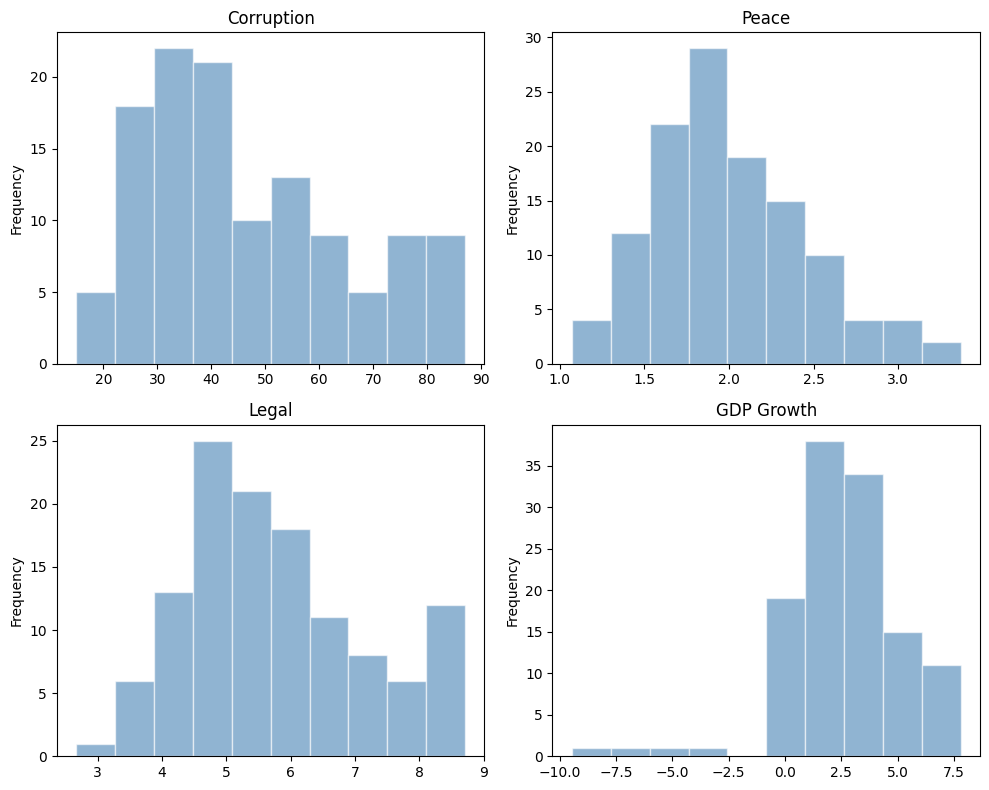

In [4]:
# plot histograms in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

raw['Corruption'].plot(kind='hist', title='Corruption', alpha=0.6, color='steelblue', edgecolor='white', ax=axes[0, 0])
raw['Peace'].plot(kind='hist', title='Peace', alpha=0.6, color='steelblue', edgecolor='white', ax=axes[0, 1])
raw['Legal'].plot(kind='hist', title='Legal', alpha=0.6, color='steelblue', edgecolor='white', ax=axes[1, 0])
raw['GDP Growth'].plot(kind='hist', title='GDP Growth', alpha=0.6, color='steelblue', edgecolor='white', ax=axes[1, 1])

plt.tight_layout()
plt.show()

### K means cluster
#### Pick features & normalization

Since Corruption and Legal are highly correlated, we drop the Corruption variable, i.e., we pick three features for this analysis, Peace, Legal and GDP Growth. Let's normalize all the features, effectively making them equally weighted.

Ref. [Feature normalization.](https://stats.stackexchange.com/questions/21222/are-mean-normalization-and-feature-scaling-needed-for-k-means-clustering)

In [5]:
df_features = raw[['Peace', 'Legal', 'GDP Growth']]
df_features_scaled = (df_features - df_features.mean()) / df_features.std()
df_features_scaled.head(5)

,Peace,Legal,GDP Growth
0,-0.390081,-0.878158,0.126952
1,0.472352,-0.958948,-0.040772
2,-0.026039,-0.484397,-2.230541
3,0.634871,-0.684553,1.303747
4,-1.261182,1.900001,-0.368418


I've included some code to drop missing values, just in case. `Kmeans` doesn't run if any row has a missing value. Of course, if there were missing values, you'd want to understand why.

In [6]:
df_features_scaled = df_features_scaled.dropna()

In [7]:
df_features_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Peace       121 non-null    float64
 1   Legal       121 non-null    float64
 2   GDP Growth  121 non-null    float64
dtypes: float64(3)
memory usage: 3.0 KB


See, no missing values. Still 121 observations.

`scikit-learn` comes with built-in scalers. Here, I'm scaling the feature data in a similar manner. The output is an *array*, not a DataFrame. 

In [8]:
df_features_scaled2 = StandardScaler().fit_transform(df_features)
df_features_scaled2[:5,:3]


array([[-0.39170288, -0.88180929,  0.12747948],
       [ 0.47431618, -0.96293527, -0.04094156],
       [-0.02614709, -0.48641154, -2.23981529],
       [ 0.63751073, -0.68739931,  1.30916848],
       [-1.26642564,  1.90790093, -0.3699501 ]])

#### Perform elbow method

This is a way to visualize how good the fit is. There are **decreasing returns** to adding more clusters. The marginal gain of adding one cluster dropped quite a bit from k=3 to k=4. We will choose k=3 (not clear cut though).

Ref. [Determining the number of clusters in a dataset.](https://en.wikipedia.org/wiki/Determining_the_number_of_clusters_in_a_data_set)

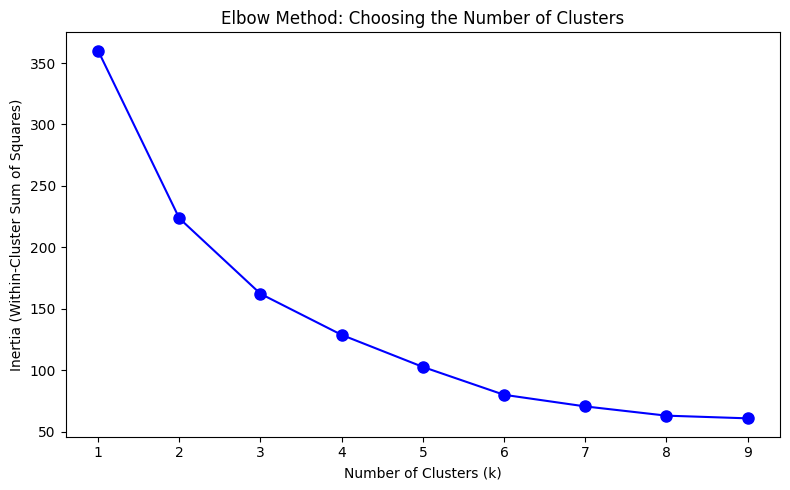

In [9]:
Ks = range(1, 10)
inertia = [KMeans(n_clusters=i, n_init='auto', random_state=42).fit(df_features_scaled).inertia_ for i in Ks]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Ks, inertia, '-bo', markersize=8)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.set_title('Elbow Method: Choosing the Number of Clusters')
ax.set_xticks(range(1, 10))

plt.tight_layout()
plt.show()

#### K means with k=3

Each country is getting labeled now. There are three categories (k=3).

In [10]:
k = 3
kmeans = KMeans(n_clusters=k, n_init='auto', random_state=1)
kmeans.fit(df_features_scaled)

# print inertia & cluster center
print("inertia for k=3 is", kmeans.inertia_)
print("cluster centers: ", kmeans.cluster_centers_)

# take a quick look at the result
y = kmeans.labels_
print("cluster labels: ", y)

inertia for k=3 is 161.2893804348309
cluster centers:  [[ 1.22973303 -0.68496051 -0.94125294]
 [ 0.16803028 -0.59729967  0.69048743]
 [-0.85097477  1.02149992 -0.23897931]]
cluster labels:  [1 1 0 1 2 2 1 0 1 2 1 1 1 2 0 1 0 1 2 0 2 1 0 2 1 2 2 0 2 1 0 1 1 2 1 2 2
 1 1 2 1 1 1 1 2 2 1 1 0 2 0 2 2 2 2 1 1 2 2 2 0 0 2 1 1 2 1 1 2 0 1 1 1 1
 1 2 2 0 0 2 2 0 1 0 1 1 2 2 2 2 0 1 0 1 1 1 2 2 2 0 2 1 2 2 2 1 1 1 0 1 0
 1 0 2 2 2 2 1 0 1 0]


#### Visualize the result (3D plot)

Three groups of countries, clustered along three dimensions of risk.

Before you make any graph, think about what you want to show and why. Sketch it on a piece of paper. You can use Chat GPT to help you with syntax **once you know what you want**. 

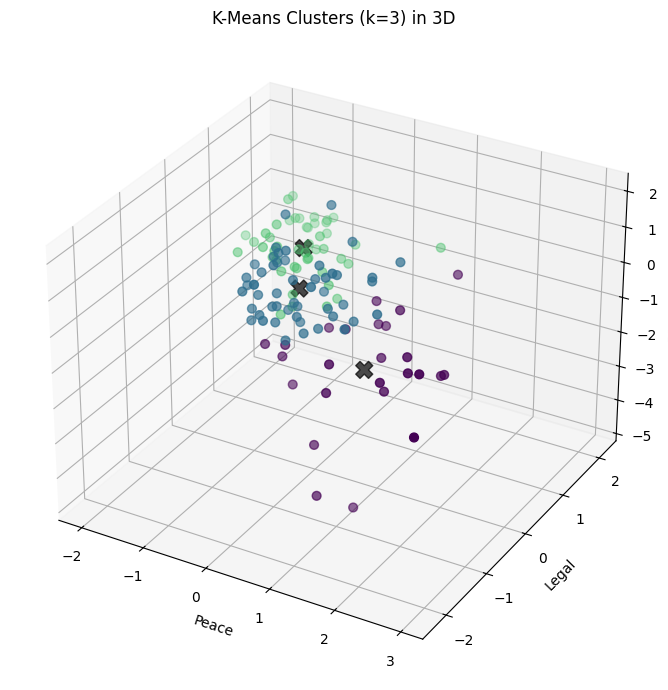

In [11]:
# set up the color
norm = clrs.Normalize(vmin=0., vmax=y.max() + 0.8)
cmap = cm.viridis

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_features_scaled.iloc[:, 0], df_features_scaled.iloc[:, 1], df_features_scaled.iloc[:, 2],
           c=cmap(norm(y)), marker='o', s=40)

centers = kmeans.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], c='black', s=150, alpha=0.7, marker='X')

ax.set_xlabel('Peace')
ax.set_ylabel('Legal')
ax.set_zlabel('GDP Growth')
ax.set_title('K-Means Clusters (k=3) in 3D')

plt.tight_layout()
plt.show()

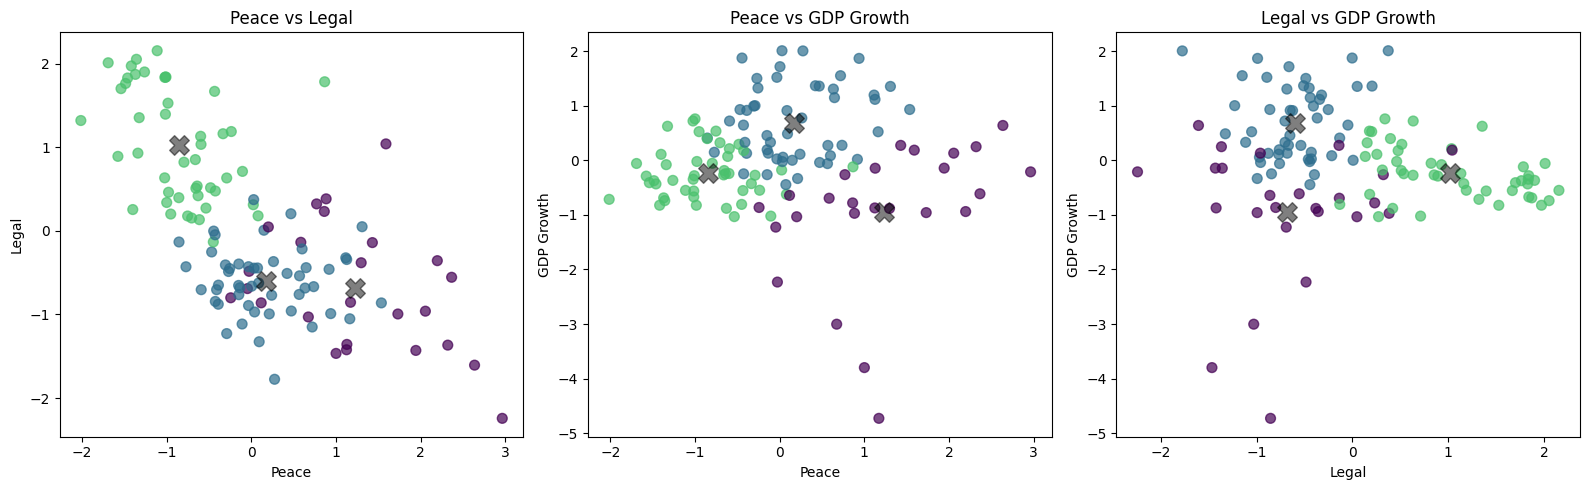

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

figs = [(0, 1), (0, 2), (1, 2)]
labels = ['Peace', 'Legal', 'GDP Growth']

for i, ax in enumerate(axes):
    ax.scatter(df_features_scaled.iloc[:, figs[i][0]], df_features_scaled.iloc[:, figs[i][1]],
               c=cmap(norm(y)), s=50, alpha=0.7)
    ax.scatter(centers[:, figs[i][0]], centers[:, figs[i][1]], c='black', s=200, alpha=0.5, marker='X')
    ax.set_xlabel(labels[figs[i][0]])
    ax.set_ylabel(labels[figs[i][1]])
    ax.set_title(f'{labels[figs[i][0]]} vs {labels[figs[i][1]]}')

plt.tight_layout()
plt.show()

#### Visualize the result (3 2D plots)

Let's plot country abbreviations instead of dots. By being careful with our graphic design, we can show dimensionality a variety of ways. 

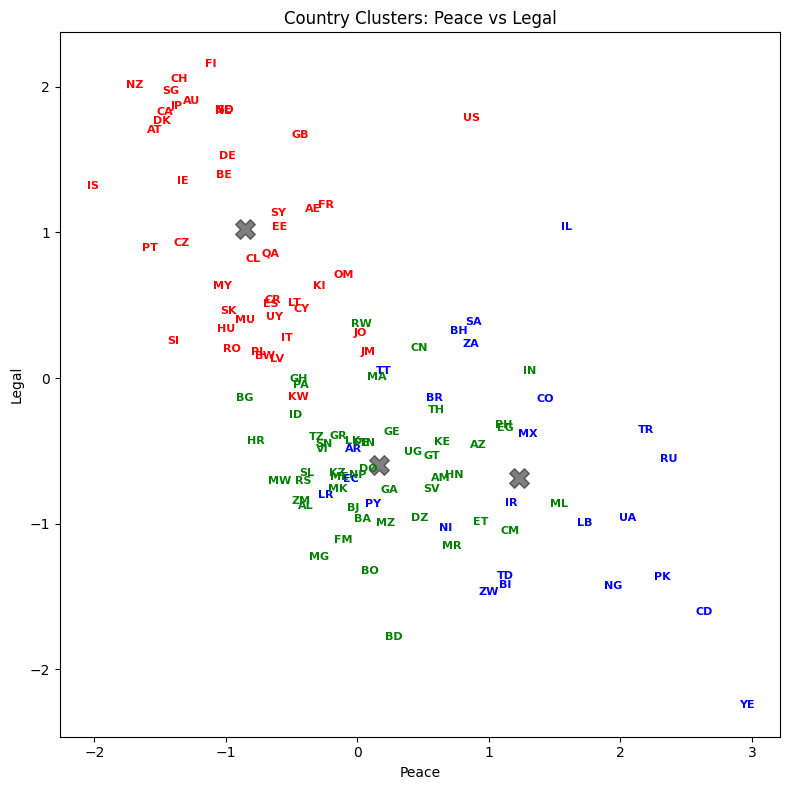

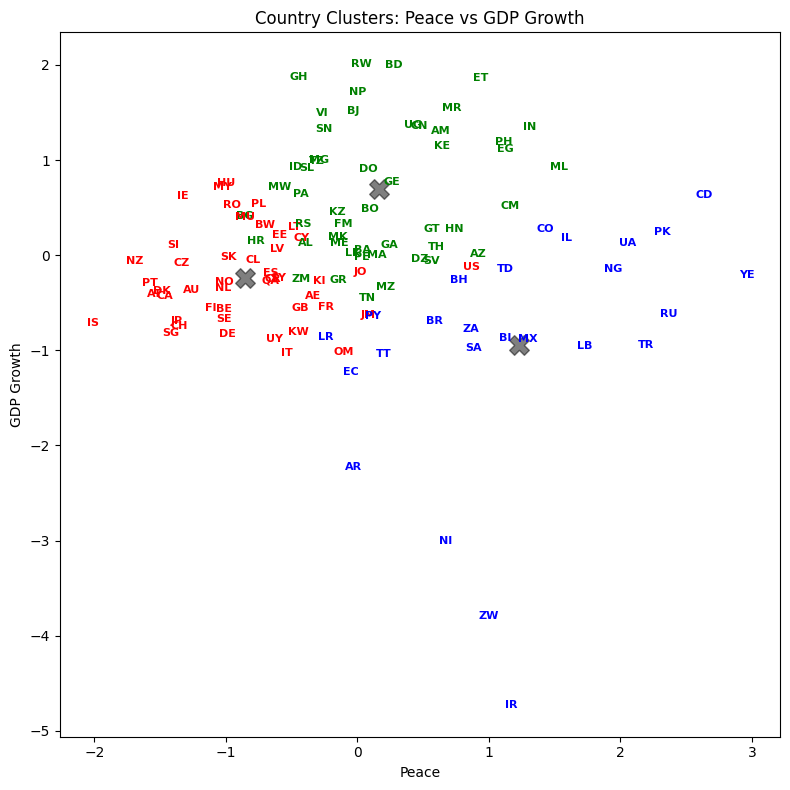

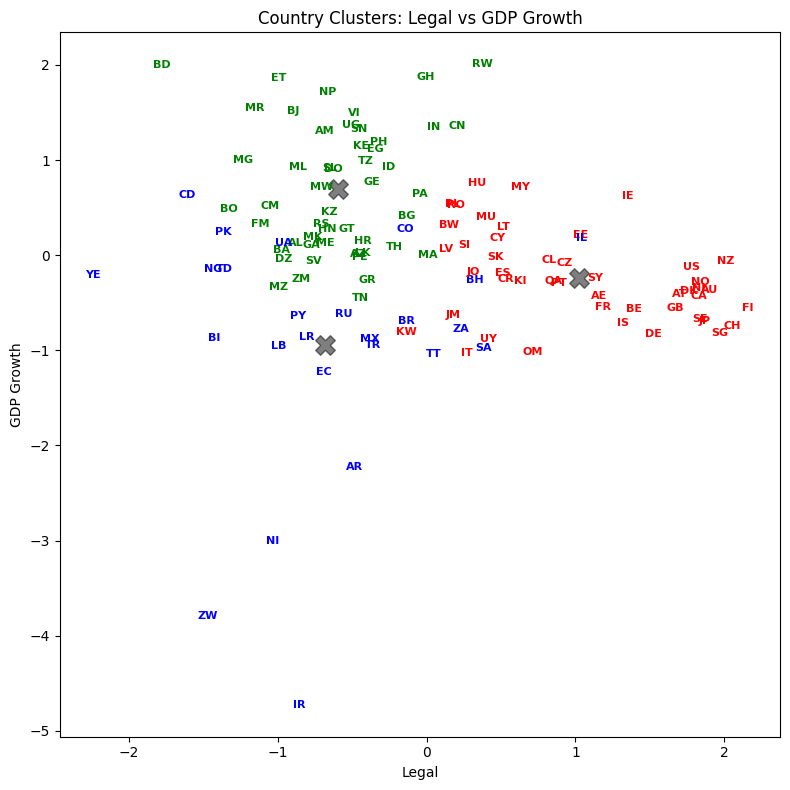

In [13]:
figs = [(0, 1), (0, 2), (1, 2)]
labels = ['Peace', 'Legal', 'GDP Growth']
colors = ['blue', 'green', 'red']

for i in range(3):
    fig, ax = plt.subplots(figsize=(8, 8))
    x_1 = figs[i][0]
    x_2 = figs[i][1]
    ax.scatter(df_features_scaled.iloc[:, x_1], df_features_scaled.iloc[:, x_2], c=y, s=0, alpha=0)
    ax.scatter(centers[:, x_1], centers[:, x_2], c='black', s=200, alpha=0.5, marker='X')
    for j in range(df_features_scaled.shape[0]):
        ax.text(df_features_scaled.iloc[j, x_1], df_features_scaled.iloc[j, x_2], raw['Abbrev'].iloc[j],
                color=colors[y[j]], weight='semibold', fontsize=8,
                horizontalalignment='center', verticalalignment='center')
    ax.set_xlabel(labels[x_1])
    ax.set_ylabel(labels[x_2])
    ax.set_title(f'Country Clusters: {labels[x_1]} vs {labels[x_2]}')
    plt.tight_layout()

plt.show()

#### List the result

Let's see how every country got classified. Who are in the same groups? Does this grouping make sense? 

In [14]:
result = pd.DataFrame({'Country':raw['Country'], 'Abbrev':raw['Abbrev'], 'Label':y})
with pd.option_context('display.max_rows', None, 'display.max_columns', 3):
    print(result.sort_values('Label'))


                          Country Abbrev  Label
60                        Lebanon     LB      0
30                        Ecuador     EC      0
48                           Iran     IR      0
50                         Israel     IL      0
61                        Liberia     LR      0
69                         Mexico     MX      0
77                      Nicaragua     NI      0
78                        Nigeria     NG      0
27   Democratic Republic of Congo     CD      0
81                       Pakistan     PK      0
90                         Russia     RU      0
92                   Saudi Arabia     SA      0
99                   South Africa     ZA      0
108           Trinidad and Tobago     TT      0
110                        Turkey     TR      0
112                       Ukraine     UA      0
118                         Yemen     YE      0
83                       Paraguay     PY      0
22                       Colombia     CO      0
120                      Zimbabwe     ZW

#### Silhouette Scores

A larger score is better. Note how `scikit-learn` has these features built-in. We don't have to do the calculation ourselves.

In [15]:
# Silhouette Analysis
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, n_init='auto', random_state=1)
    cluster_labels = clusterer.fit_predict(df_features_scaled)
    silhouette_avg = silhouette_score(df_features_scaled, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette score is: {silhouette_avg:.4f}")

For n_clusters = 2, the average silhouette score is: 0.3509
For n_clusters = 3, the average silhouette score is: 0.3529
For n_clusters = 4, the average silhouette score is: 0.3163
For n_clusters = 5, the average silhouette score is: 0.2770
For n_clusters = 6, the average silhouette score is: 0.3358
For n_clusters = 7, the average silhouette score is: 0.3110
For n_clusters = 8, the average silhouette score is: 0.3501
For n_clusters = 9, the average silhouette score is: 0.3460
For n_clusters = 10, the average silhouette score is: 0.3173


The silhouette scores are relatively flat across different values of k, hovering around 0.31-0.35. This tells us that the data doesn't have dramatically distinct clusters — the boundaries between groups are somewhat fuzzy. That's actually common with real-world data, especially country-level economic indicators where there's a continuum from low-risk to high-risk.

The highest silhouette score is at k=3, which is consistent with our elbow method choice. A silhouette score ranges from -1 to 1:

- **Close to 1**: The observation is well-matched to its own cluster and poorly matched to neighboring clusters
- **Close to 0**: The observation is on the border between two clusters
- **Negative**: The observation may have been assigned to the wrong cluster

A score around 0.35 is moderate — it suggests meaningful but not perfectly separated clusters. In finance, perfectly separated clusters are rare. Markets and economies exist on a spectrum.

## Principal Component Analysis (PCA)

Chapter 2 ends with a discussion of **principal component analysis (PCA)**. PCA is one of the most important tools in data analysis, especially in finance.

PCA takes the data features and creates **factors** from the data that are **uncorrelated** with each other. From pg. 42:

> PCA works best on normalized data. The first factor accounts for as  much of the variability in the data as possible. Each succeeding factor  then accounts for as much of the remaining variability in the data subject to the condition that it is uncorrelated to preceding factors. The  quantity of a particular factor in a particular observation is the factor score. 

**What's the intuition?** Imagine you have a cloud of data points in 3D space, shaped like a football (an American football — elongated). If you wanted to summarize the shape of that cloud with just one direction, you'd pick the long axis — that's where the data spreads out the most. That direction is your first principal component. The second component points across the width, capturing the next most variation while being perpendicular (uncorrelated) to the first. The third captures whatever's left.

PCA does exactly this, but in any number of dimensions. It finds the directions (called **principal components** or **eigenvectors**) along which your data varies the most. The amount of variation captured by each component is the **explained variance**.

**Why is this useful in finance?** Suppose you have returns for 50 stocks. That's 50 dimensions of data. PCA might reveal that just 3-4 principal components explain 80-90% of the variation in returns. Those components often correspond to interpretable factors — the overall market, sector rotation, value vs. growth. Instead of tracking 50 correlated stocks, you can focus on a few uncorrelated components that capture the essential behavior.

The key outputs from PCA are:

- **Components (loadings)**: The weights that define each principal component as a linear combination of the original features. They tell you what each component "means."
- **Explained variance ratio**: The fraction of total variance captured by each component. This tells you how important each component is.
- **Principal component scores**: The transformed data — each observation's coordinates in the new principal component space.

You can read more about how to do this with [Scikit-learn PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).

What is PCA really doing mathematically? You need some [matrix algebra for that](https://brilliant.org/wiki/principal-component-analysis/). Here's [another explainer](https://www.avenga.com/magazine/pca-in-finance/), with the bare-minimum of math.

This video was recommended by [QuantyMacro](https://www.quantymacro.com).

[![PCA Explained](https://img.youtube.com/vi/fkf4IBRSeEc/0.jpg)](https://www.youtube.com/watch?v=fkf4IBRSeEc)

Let's start with some simple PCA code using our scaled features.

In [16]:
from sklearn.decomposition import PCA

df_features_scaled_pca = raw[['Corruption', 'Peace', 'Legal', 'GDP Growth']]

df_features_scaled_pca = (df_features_scaled_pca - df_features_scaled_pca.mean()) / df_features_scaled_pca.std()
df_features_scaled_pca.head(5)


,Corruption,Peace,Legal,GDP Growth
0,-0.633230,-0.390081,-0.878158,0.126952
1,-0.633230,0.472352,-0.958948,-0.040772
2,-0.098542,-0.026039,-0.484397,-2.230541
3,-0.258948,0.634871,-0.684553,1.303747
4,1.612460,-1.261182,1.900001,-0.368418


The code below defines an object called *pca*. We then apply the method `.fit` to this object using the full set of scaled data - I didn't drop Corruption this time. 

In [17]:
pca = PCA(n_components=4)
pca.fit(df_features_scaled_pca)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",4
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [18]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("\nCumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))

# Create a loadings DataFrame for easier interpretation
features = ['Corruption', 'Peace', 'Legal', 'GDP Growth']
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3', 'PC4'],
    index=features
)

print("\nPCA Loadings (how each feature contributes to each component):\n")
print(loadings.round(3))

Explained variance ratio: [0.64020312 0.25059185 0.09438808 0.01481695]

Cumulative explained variance: [0.64020312 0.89079497 0.98518305 1.        ]

PCA Loadings (how each feature contributes to each component):

              PC1    PC2    PC3    PC4
Corruption  0.602  0.015  0.328  0.728
Peace      -0.524 -0.201  0.825  0.065
Legal       0.594 -0.022  0.425 -0.683
GDP Growth -0.103  0.979  0.174 -0.013


Let's interpret these results:

- `explained_variance_ratio_` tells us how much of the total variance each component captures. The first component explains about 64% of the variance, and the first two together explain about 89%. This means we could reduce our four features to just two principal components and still retain most of the information.

- The **loadings** show how each original feature contributes to each principal component. PC1 loads heavily (negatively) on Corruption and Legal, and positively on Peace. Countries with high corruption tend to have weak legal systems, so PC1 is essentially a "governance quality" factor.

- PC2 loads almost entirely on GDP Growth (loading of -0.98). This component captures economic dynamism, independent of governance.

Note how the signs can be reversed and it doesn't matter, as Hull mentions. What matters is the relative magnitude and direction of the loadings.

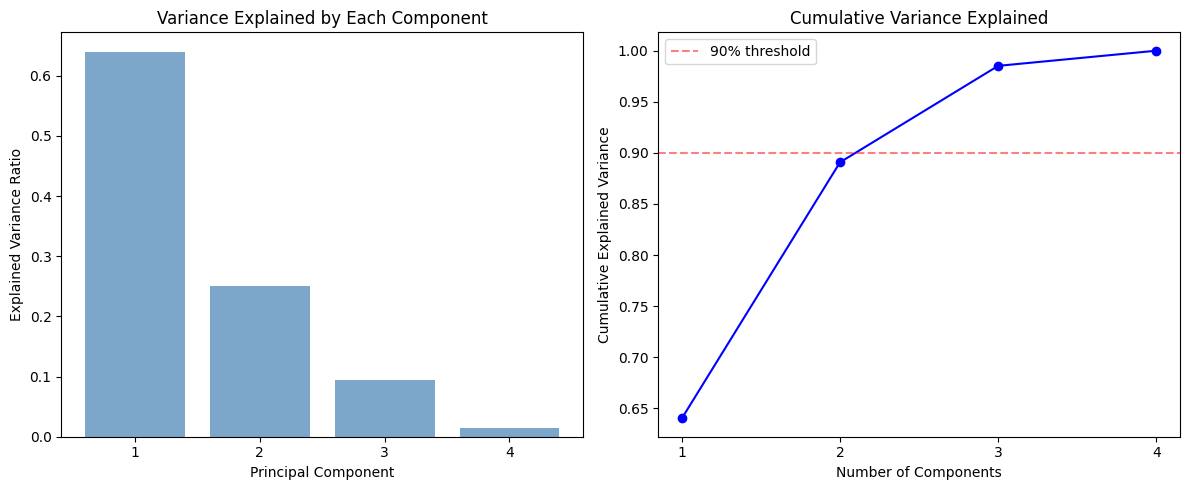

In [19]:
# Visualize explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart of individual explained variance
ax1.bar(range(1, 5), pca.explained_variance_ratio_, alpha=0.7, color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Variance Explained by Each Component')
ax1.set_xticks(range(1, 5))

# Cumulative explained variance
cumulative = np.cumsum(pca.explained_variance_ratio_)
ax2.plot(range(1, 5), cumulative, '-bo')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Variance Explained')
ax2.set_xticks(range(1, 5))
ax2.axhline(y=0.9, color='r', linestyle='--', alpha=0.5, label='90% threshold')
ax2.legend()

plt.tight_layout()
plt.show()

The left chart is a **scree plot** — a bar chart of how much variance each principal component explains. PC1 dominates, capturing about 64% of the total variance. PC2 adds another 25%. Together, the first two components explain about 89% of the variation in our four features.

The right chart shows the cumulative explained variance. The red dashed line marks 90%. Two components get us very close to that threshold. In practice, you look at this chart and decide how many components to keep. A common rule of thumb is to keep enough components to explain 80-90% of the variance.

Let's also visualize the countries in this reduced principal component space.

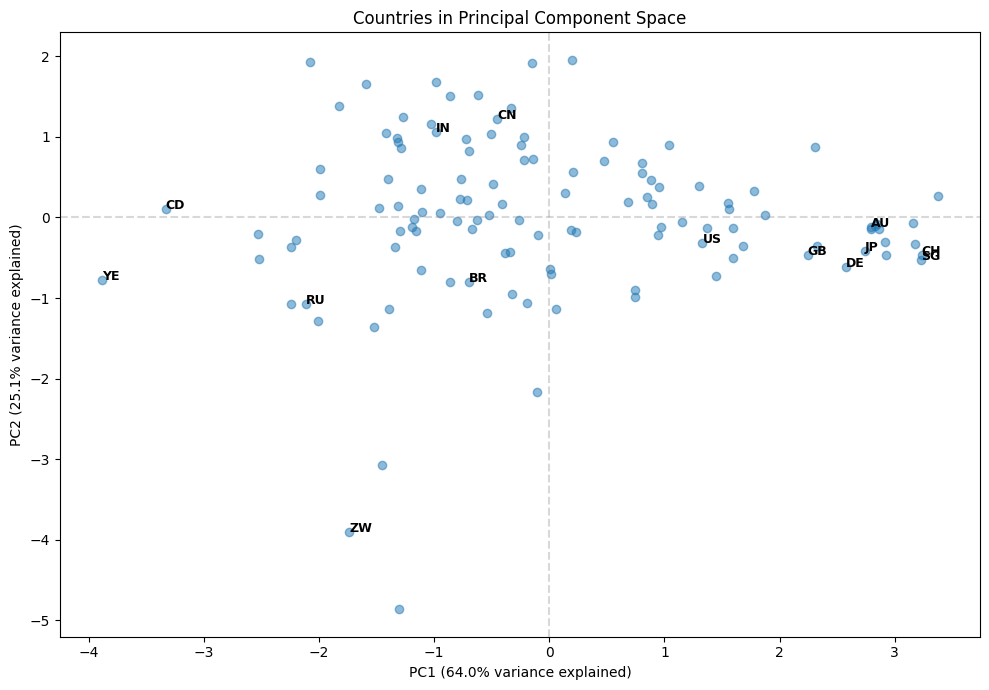

In [20]:
# Transform data to principal component space
pc_scores = pca.transform(df_features_scaled_pca)

# Plot first two principal components
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(pc_scores[:, 0], pc_scores[:, 1], alpha=0.5)

# Label selected countries for context
highlight = ['US', 'CN', 'RU', 'BR', 'IN', 'JP', 'DE', 'GB', 'AU', 'ZW', 'YE', 'CH', 'SG', 'CD']
for i in range(len(raw)):
    if raw['Abbrev'].iloc[i] in highlight:
        ax.annotate(raw['Abbrev'].iloc[i], (pc_scores[i, 0], pc_scores[i, 1]),
                     fontsize=9, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance explained)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance explained)')
ax.set_title('Countries in Principal Component Space')
ax.axhline(y=0, color='grey', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='grey', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

This scatter plot shows each country positioned by its first two principal component scores. PC1 (the x-axis) is mostly about governance quality — countries on the left have higher corruption and weaker legal systems, while countries on the right have better governance. PC2 (the y-axis) is mostly about GDP growth — countries lower on the plot are growing faster.

You can see natural groupings emerge. The developed nations (US, GB, JP, AU, CH, SG, DE) cluster on the right — strong governance but varying growth rates. Countries like Zimbabwe (ZW), Yemen (YE), and DR Congo (CD) are on the left — weaker governance. China (CN) and India (IN) sit in the middle on governance but tend toward higher GDP growth.

This is the power of PCA: by reducing four dimensions to two, we can **visualize** the essential structure of the data and see relationships that would be hard to spot in the raw numbers.

Hull notes when PCA is used. In particular, we can use it to shrink the number of features in our models. It can combine features together. 

> PCA is sometimes used in supervised learning as well as unsupervised learning. We can use it to replace a long list of features by a much smaller list of manufactured features derived from a PCA. The manufactured features are chosen so that they account for most of the variability in the data we are using for prediction and have the nice property that they are uncorrelated. 

In our country risk example, PCA reduced four correlated features into four uncorrelated components. But the first two components capture about 89% of the total variance. This means we could represent each country with just two numbers (their PC1 and PC2 scores) instead of four, while losing very little information.

This **dimensionality reduction** becomes even more powerful with larger datasets. Imagine working with hundreds of financial variables — PCA can boil them down to a manageable number of uncorrelated factors that capture the essential patterns.

One common application is using PCA to **shrink** the number of factors in a [variance-covariance matrix](https://www.ocean.washington.edu/courses/ess522/lectures/14_covarianceandPCA.pdf). This is especially relevant in portfolio risk management, where estimating a large covariance matrix directly is unreliable with limited data.